# Credit Card Fraud Detection

## Executive Summary

This project predicts fraudulent credit card transactions on a highly imbalanced
dataset (fraud rate < 1%). The goal is to flag suspicious transactions in real
time while keeping false positives manageable enough for production use.

**Key Findings**
- **Outliers are the signal, not noise** — 76% of all fraud occurs in the outlier
  region of transaction amount. Instead of removing them, log1p + RobustScaler
  was used to preserve their predictive power.
- **Behavioral velocity matters more than static features** — rolling 1h/24h
  transaction counts, amounts, and "amount vs 24h mean" ratios capture sudden
  deviations that single-transaction features miss.
- **High-cardinality features need careful encoding** — target encoding with
  min-sample threshold (50) + Bayesian smoothing (k=100) prevents small-group
  noise from contaminating the model.
- **XGBoost outperforms all other models** — PR-AUC 0.9750, F1 0.92 on the
  held-out test set using the original class distribution + scale_pos_weight.

**Approach**
EDA with fraud rate by feature → Temporal / age / amount feature engineering →
Velocity feature engineering (rolling windows per card) → Target encoding with
smoothing for high-cardinality fields (state, city, job, merchant) →
Outlier-preserving scaling (log1p + RobustScaler) → Class imbalance handling
with 3 strategies → Model comparison (5 algorithms × 3 strategies) →
Threshold tuning → Business Case Analysis

**Outcome**
XGBoost with original distribution + scale_pos_weight achieves PR-AUC 0.9750
and F1 0.92. A two-threshold deployment system is recommended: auto-block at
≥ 0.992 (26 false blocks per 6 months) and review queue for scores between
0.014–0.992 (~17 reviews/day), recovering an estimated additional USD 175K in
fraud prevention compared to single-threshold auto-block alone.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
pd.set_option('display.max_columns', None)
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv
/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")    
sns.set_palette(["#FF6B6B", "#4ECDC4", "#45B7D1", "#96CEB4", "#FFEAA7"])

In [3]:
train_path = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv'
test_path = '/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv'
df = pd.read_csv(train_path, index_col=0)
test = pd.read_csv(test_path, index_col=0)

In [4]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [5]:
print(df[df['is_fraud']==1]['amt'].describe())
print("\nMean:", df[df['is_fraud']==1]['amt'].mean())
print("Median:", df[df['is_fraud']==1]['amt'].median())

count    7506.000000
mean      531.320092
std       390.560070
min         1.060000
25%       245.662500
50%       396.505000
75%       900.875000
max      1376.040000
Name: amt, dtype: float64

Mean: 531.3200919264589
Median: 396.505


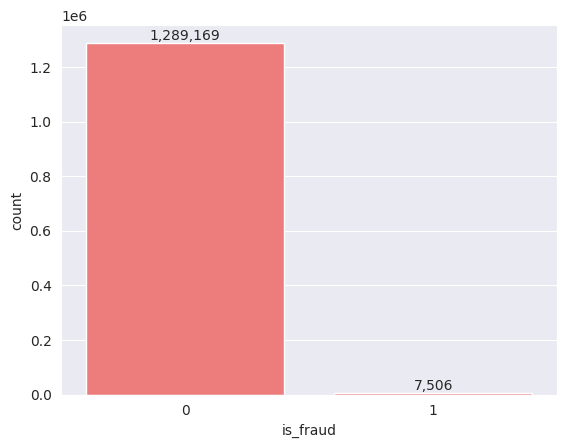

In [6]:
ax = sns.countplot(data=df, x='is_fraud')

ax.bar_label(ax.containers[0], fmt='{:,.0f}')  
plt.show()

## Data Summary

- The dataset is **highly imbalanced**, so **PR-AUC** will be used as the primary evaluation metric for the model.
- **No NaN values** or **duplicate records** were found in the dataset.

In [7]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [8]:
def get_age(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Compute customer age from 'dob' and drop unused columns.

    Uses 2021 as the reference year because the dataset covers transactions
    from January 2019 to December 2020. Fixing the year keeps `age` consistent
    across all rows and reproducible (independent of the run date).
    """
    
    dataframe['dob'] = pd.to_datetime(dataframe['dob'], format='%Y-%m-%d')
    dataframe['age'] = 2021 - dataframe['dob'].dt.year
    return dataframe

In [9]:
def split_date_n_time(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Extracts and transforms date/time features from 'trans_date_trans_time'.
    - Splits into date and time components
    - Derives Day, Month, Hour features
    - Bins Hour into time periods: Night / Morning / Afternoon / Evening
    - Drops intermediate columns after extraction
    """
    # Split 'trans_date_trans_time' into separate date and time columns
    dataframe[['trans_date', 'trans_time']] = dataframe['trans_date_trans_time'].str.split(expand=True)
    
    # Convert to datetime format for feature extraction
    dataframe['trans_date'] = pd.to_datetime(dataframe['trans_date'], format='%Y-%m-%d')
    dataframe['trans_time'] = pd.to_datetime(dataframe['trans_time'], format='%H:%M:%S')
    
    # Extract Day, Month, Hour, IsWeekEnd features
    dataframe['Day'] = dataframe['trans_date'].dt.dayofweek
    dataframe['Month'] = dataframe['trans_date'].dt.month
    dataframe['Hour'] = dataframe['trans_time'].dt.hour
    dataframe['IsWeekEnd'] = dataframe['trans_date'].dt.dayofweek.isin([5,6]).astype(int)
    
    # Drop intermediate columns that are no longer needed
    dataframe.drop(columns=['trans_date', 'trans_time'], inplace=True)
    # Keep trans_date_trans_time for velocity feature
    return dataframe

In [10]:
def bin_age(dataframe):
    """
    Bins the 'age' column into meaningful age groups.
    - Student / Young Adult / Adult / Middle Age / Senior / Elderly
    - Uses open-ended bounds to handle unseen values in test set
    """
    bins = [float('-inf'), 23, 30, 45, 60, 75, float('inf')]
    labels = ['Student', 'Young Adult', 'Adult', 'Middle Age', 'Senior', 'Elderly']
    dataframe['age_group'] = pd.cut(dataframe['age'], bins=bins, labels=labels, right=False)
    return dataframe

In [11]:
df = get_age(df)
df = split_date_n_time(df)
df = bin_age(df)

test = get_age(test)
test = split_date_n_time(test)
test = bin_age(test)

In [12]:
def create_velocity_features_combined(train_df, test_df):
    """
    Create velocity (time-based aggregation) features per credit card,
    computed over the COMBINED train+test timeline so that cards spanning
    the train/test boundary keep their real transaction history instead
    of resetting to a cold start at the beginning of the test file.
    """
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['_split'] = 'train'
    test_df['_split']  = 'test'

    combined = pd.concat([train_df, test_df], ignore_index=True)
    combined['datetime'] = pd.to_datetime(combined['trans_date_trans_time'])
    combined = combined.sort_values(['cc_num', 'datetime']).reset_index(drop=True)

    # --- Time since last transaction (seconds) ---
    combined['time_since_last'] = (
        combined.groupby('cc_num')['datetime']
                .diff()
                .dt.total_seconds()
                .fillna(999999)
    )

    # --- Rolling 1 hour ---
    rolling_1h = combined.groupby('cc_num').rolling('1h', on='datetime')['amt']
    combined['txn_count_1h'] = rolling_1h.count().values
    combined['amt_sum_1h']   = rolling_1h.sum().values

    # --- Rolling 24 hour ---
    rolling_24h = combined.groupby('cc_num').rolling('24h', on='datetime')['amt']
    combined['amt_mean_24h'] = rolling_24h.mean().values

    # --- Ratio ---
    combined['amt_vs_mean_24h'] = combined['amt'] / combined['amt_mean_24h'].replace(0, 1)

    combined.drop(columns=['datetime'], inplace=True)

    train_out = combined[combined['_split'] == 'train'].drop(columns='_split').reset_index(drop=True)
    test_out  = combined[combined['_split'] == 'test'].drop(columns='_split').reset_index(drop=True)
    return train_out, test_out


df, test = create_velocity_features_combined(df, test)

In [13]:
val_mask = pd.to_datetime(df['trans_date_trans_time']) >= '2020-03-01'

df_train = df.loc[~val_mask].copy().reset_index(drop=True)
df_val   = df.loc[val_mask].copy().reset_index(drop=True)

print(f"df_train: {df_train.shape}, fraud rate: {df_train['is_fraud'].mean():.4f}")
print(f"df_val:   {df_val.shape}, fraud rate: {df_val['is_fraud'].mean():.4f}")
print(f"test:     {test.shape}, fraud rate: {test['is_fraud'].mean():.4f}")

df_train: (1024843, 33), fraud rate: 0.0058
df_val:   (271832, 33), fraud rate: 0.0059
test:     (555719, 33), fraud rate: 0.0039


In [14]:
print(df_train['trans_date_trans_time'].max()) 
print(df_val['trans_date_trans_time'].min())     
print(len(df_train) + len(df_val) == len(df))    

2020-02-28 23:59:45
2020-03-01 00:02:20
True


In [15]:
df_train.sample(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,Day,Month,Hour,IsWeekEnd,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h
486792,2019-05-26 00:37:04,3502377050801561,fraud_Rau and Sons,grocery_pos,96.49,Kathleen,Martin,F,659 Nicole Cove Suite 560,New Waverly,TX,77358,30.5354,-95.4532,4993,"Scientist, biomedical",1948-11-30,cc218b317b45c304aea3e139a7843b6d,1337992624,30.996664,-95.321921,0,73,6,5,0,1,Senior,37255.0,1.0,96.49,66.215000,1.457223
822141,2019-12-11 16:59:33,4951647200979051,"fraud_Lang, Towne and Schuppe",kids_pets,41.43,Kimberly,Miller,F,75533 Tamara Valleys,Logan,IL,62856,37.9943,-88.9417,324,"Scientist, research (physical sciences)",1976-06-15,e0912378006f7c3939fa3dd003806ba5,1355245173,37.952949,-88.982010,0,45,2,12,16,0,Middle Age,9629.0,1.0,41.43,58.475000,0.708508
113638,2019-12-09 00:28:09,4562827002127,"fraud_Lind, Huel and McClure",gas_transport,66.00,Christopher,Johnson,M,28711 Kristine Junction Suite 309,Greenville,OH,45331,40.0987,-84.6342,22930,Media planner,1971-11-26,8b571ceea3eea080693904f0feb1a145,1355012889,40.832986,-85.526942,0,50,0,12,0,0,Middle Age,17288.0,1.0,66.00,38.792222,1.701372
932223,2019-06-25 01:04:18,4040099974063068803,fraud_Bauch-Raynor,grocery_pos,114.21,Jeffrey,Lewis,M,24255 Bryan Square,Palermo,ND,58769,48.3396,-102.2400,229,Administrator,1983-03-20,4b3ae90d5a8e1d4aa7d536a4cfbda842,1340586258,49.096141,-101.250791,0,38,1,6,1,0,Adult,14433.0,1.0,114.21,293.942500,0.388545
685045,2019-10-06 16:21:43,4129767952109660,"fraud_Dare, Casper and Bartoletti",kids_pets,12.88,Cheryl,Ballard,F,248 James Squares Apt. 838,Halstad,MN,56548,47.3551,-96.7980,771,"Scientist, audiological",1972-06-14,8a61354d606e4a97705d37a917d64ca7,1349540503,46.395250,-97.551032,0,49,6,10,16,1,Middle Age,77352.0,1.0,12.88,15.725000,0.819078


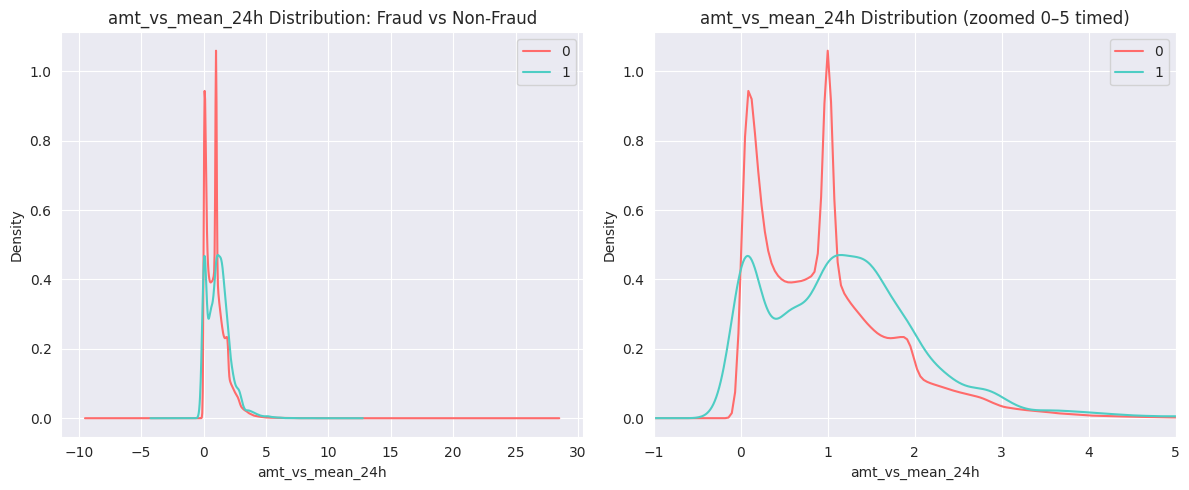

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df_train.groupby('is_fraud')['amt_vs_mean_24h'].plot(
    kind='kde', legend=True, ax=ax[0]
)
ax[0].set_title('amt_vs_mean_24h Distribution: Fraud vs Non-Fraud')
ax[0].set_xlabel('amt_vs_mean_24h')


df_train.groupby('is_fraud')['amt_vs_mean_24h'].plot(
    kind='kde', legend=True, ax=ax[1]
)
ax[1].set_xlim(-1, 5)
ax[1].set_title('amt_vs_mean_24h Distribution (zoomed 0–5 timed)')
ax[1].set_xlabel('amt_vs_mean_24h')

plt.tight_layout()
plt.show()

In [17]:
print("amt range:", df_train['amt'].min(), "to", df_train['amt'].max())
print("amt_mean_24h range:", df_train['amt_mean_24h'].min(), "to", df_train['amt_mean_24h'].max())
print("amt_vs_mean_24h range:", df_train['amt_vs_mean_24h'].min(), "to", df_train['amt_vs_mean_24h'].max())

amt range: 1.0 to 28948.9
amt_mean_24h range: 1.0 to 14407.25
amt_vs_mean_24h range: 0.00032154443090345864 to 19.002735172939097


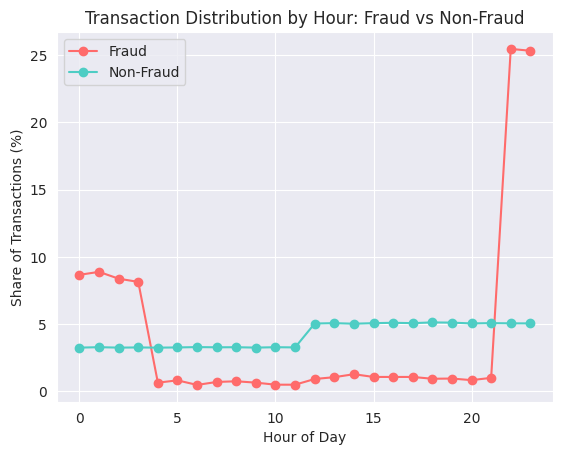

In [18]:
fraud_dist = df_train[df_train['is_fraud'] == 1]['Hour'].value_counts(normalize=True).sort_index() * 100
nonfraud_dist = df_train[df_train['is_fraud'] == 0]['Hour'].value_counts(normalize=True).sort_index() * 100

ax = fraud_dist.plot(label='Fraud', marker='o')
nonfraud_dist.plot(ax=ax, label='Non-Fraud', marker='o')

ax.set_title('Transaction Distribution by Hour: Fraud vs Non-Fraud')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Share of Transactions (%)')
ax.legend()
plt.show()

In [19]:
def create_is_night(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Converts 'Hour' into a binary 'is_night' feature.
    - Day (0): Hour 5–20
    - Night (1): Hour 0–4 and 21–23
    """
    dataframe['is_night'] = (~dataframe['Hour'].between(5, 20)).astype(int)
    return dataframe

df_train = create_is_night(df_train)
df_val = create_is_night(df_val)
test = create_is_night(test)

In [20]:
def plot_fraud_rate(ax, data, group_col, title):
    """Plot mean fraud rate per category in `group_col` as a labeled bar chart."""
    fraud_rate = data.groupby(group_col, observed=True)['is_fraud'].mean().reset_index()
    
    bars = fraud_rate.set_index(group_col).plot(kind='bar', ax=ax, rot=90)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Proportion')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', label_type='edge', fontsize=9, padding=2)

    ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

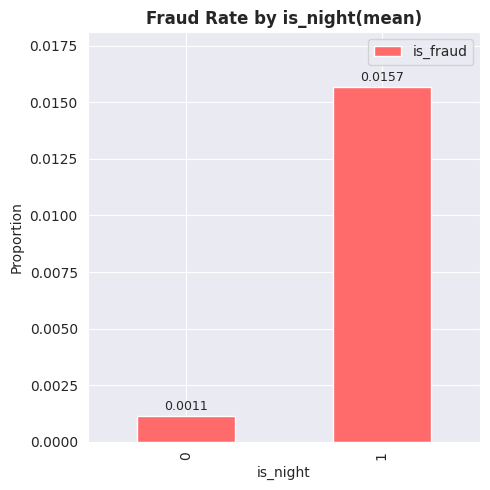

In [21]:
fig, ax = plt.subplots(figsize = (5,5))
plot_fraud_rate(ax, df_train, 'is_night', 'Fraud Rate by is_night(mean)')
plt.tight_layout()
plt.show()

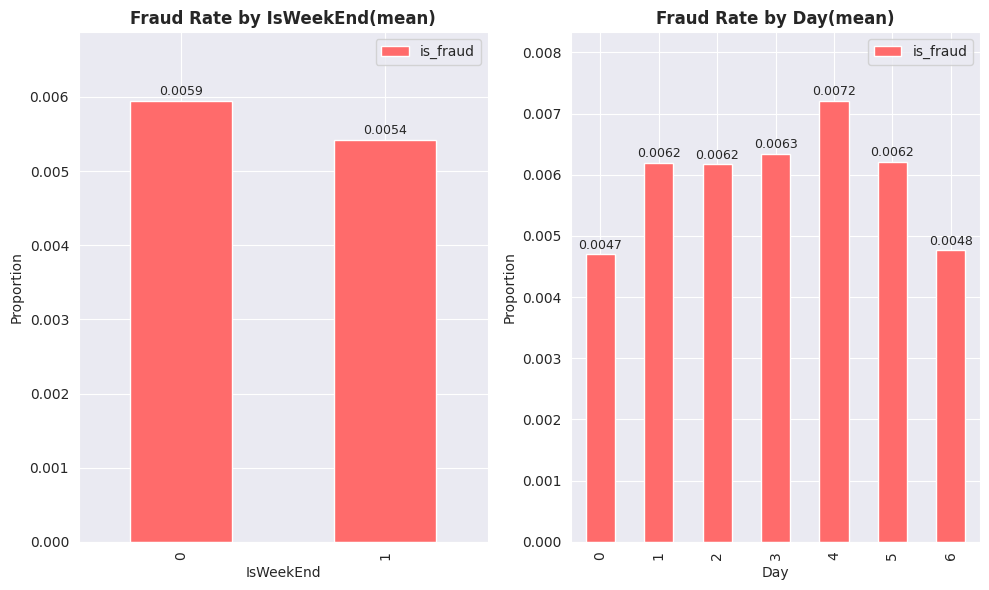

In [22]:
fig, ax = plt.subplots(1,2 , figsize=(10,6))
plot_fraud_rate(ax[0], df_train, 'IsWeekEnd', 'Fraud Rate by IsWeekEnd(mean)')

plot_fraud_rate(ax[1], df_train, 'Day', 'Fraud Rate by Day(mean)')

plt.tight_layout()
plt.show()

### Decision

> - `IsWeekEnd` will be **dropped** — redundant with `Day` and based on an incorrect hypothesis (weekends are not riskier).
> - `Day` will be **kept** 


In [23]:
df_train.drop('IsWeekEnd', axis=1, inplace=True)
df_val.drop('IsWeekEnd', axis=1, inplace=True)
test.drop('IsWeekEnd', axis=1, inplace=True)

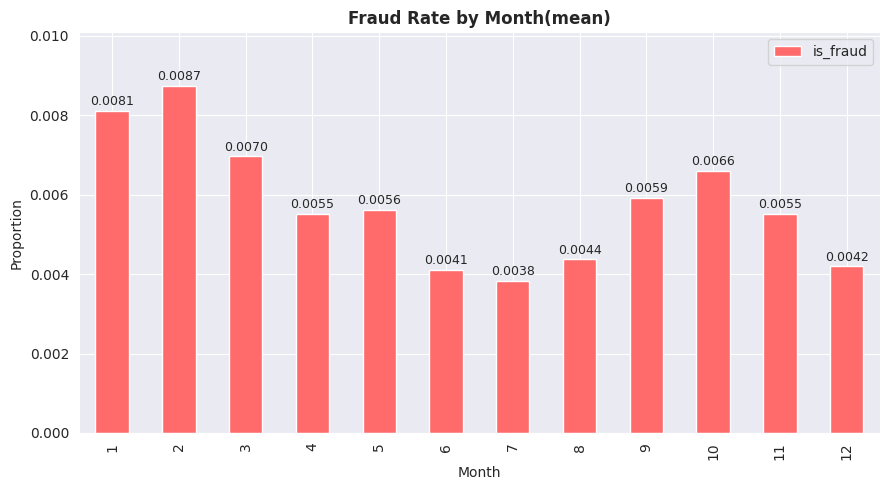

In [24]:
fig, ax = plt.subplots(figsize = (9,5))
plot_fraud_rate(ax, df_train, 'Month', 'Fraud Rate by Month(mean)')
plt.tight_layout()
plt.show()

### Fraud Rate by Month

- **Highest risk:** January (0.81%) and February (0.87%) — early-year months show fraud rates roughly **2× higher** than the low-season months.
- **Lowest risk:** July (0.38%) and December (0.42%).
- Overall fraud rate ranges from ~0.4% to ~0.9%, with a clear seasonal pattern: Q1 elevated, mid-year (Jun–Aug) lowest, slight rebound in Sep–Oct.
- Suggests **Month** could be a useful feature for the model, or at least worth encoding as a seasonal signal (e.g. quarter or `is_q1`).

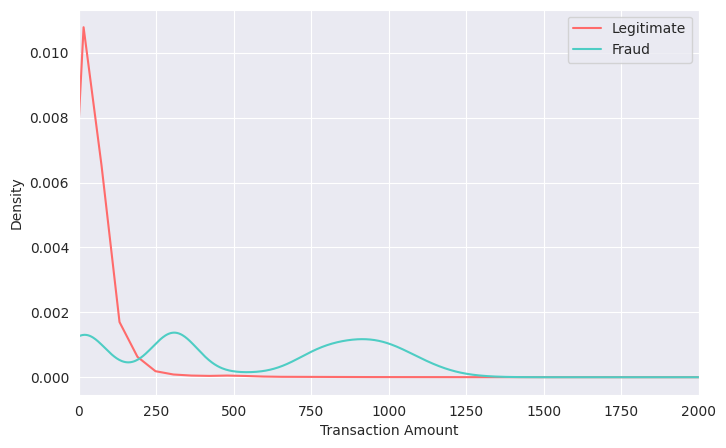

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
df_train[df_train['is_fraud'] == 0]['amt'].plot(kind='kde', ax=ax, label='Legitimate')
df_train[df_train['is_fraud'] == 1]['amt'].plot(kind='kde', ax=ax, label='Fraud')
ax.set_xlim(0, 2000)
ax.set_xlabel('Transaction Amount')
ax.legend()
plt.show()

Non-fraud (0): Heavily concentrated near $0, dropping sharply at higher amounts

Fraud (1): Shows a bimodal distribution with two peaks around $100 and $500

### Decision

amt will be binned into 3 groups to capture the bimodal pattern:

    Low  : amt 0 to 100
    Mid  : amt 100 to 500
    High : amt above 500

In [26]:
def bin_amt(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Bins 'amt' into 3 groups based on fraud distribution pattern."""
    bins = [0, 100, 500, float('inf')]
    labels = ['Low', 'Mid', 'High']
    dataframe['amt_group'] = pd.cut(dataframe['amt'], bins=bins, labels=labels)
    return dataframe

df_train = bin_amt(df_train)
df_val   = bin_amt(df_val)
test     = bin_amt(test)

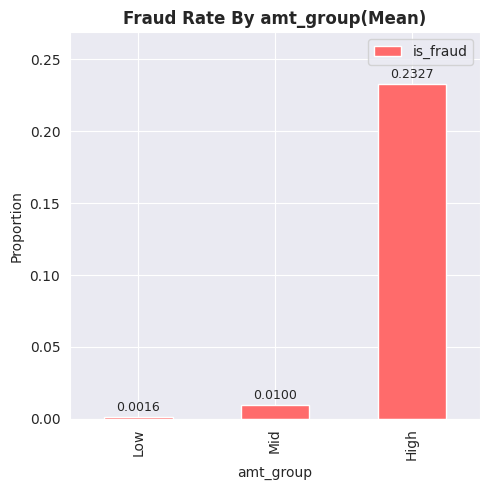

In [27]:
fig, ax = plt.subplots(figsize=(5,5))
plot_fraud_rate(ax, df_train, 'amt_group', 'Fraud Rate By amt_group(Mean)')
plt.tight_layout()
plt.show()

In [28]:
baseline = df_train['is_fraud'].mean()

amt_stats = (df_train.groupby('amt_group', observed=True)
               .agg(
                   total_txns=('is_fraud', 'count'),
                   fraud_txns=('is_fraud', 'sum')
               )
               .assign(
                   fraud_rate=lambda x: x['fraud_txns'] / x['total_txns'],
                   lift=lambda x: x['fraud_txns'] / x['total_txns'] / baseline
               ))

amt_stats

,total_txns,fraud_txns,fraud_rate,lift
amt_group,,,,
Low,839710,1308,0.001558,0.270618
Mid,172809,1723,0.009971,1.732199
High,12324,2868,0.232717,40.430248


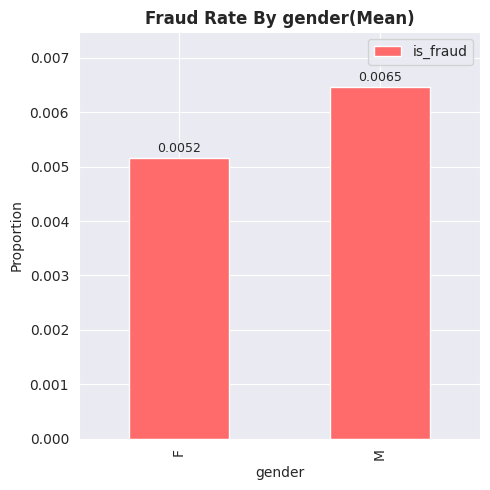

In [29]:
fig, ax = plt.subplots(figsize=(5,5))
plot_fraud_rate(ax, df_train, 'gender', 'Fraud Rate By gender(Mean)')
plt.tight_layout()
plt.show()


The ratio of 1.21x indicates a **weak signal**, comparable to other features previously identified as low-value predictors (e.g. `state_fraud_rate`, `age`).

**Decision: Drop `gender` from the feature set.**

Reasoning:
- **Weak predictive power** — the difference between groups is small and likely overlaps with information already captured by stronger features such as `job_fraud_rate` and `city_fraud_rate`.

In [30]:
df_train.drop('gender', axis=1, inplace=True)
df_val.drop('gender', axis=1, inplace=True)
test.drop('gender', axis=1, inplace=True)

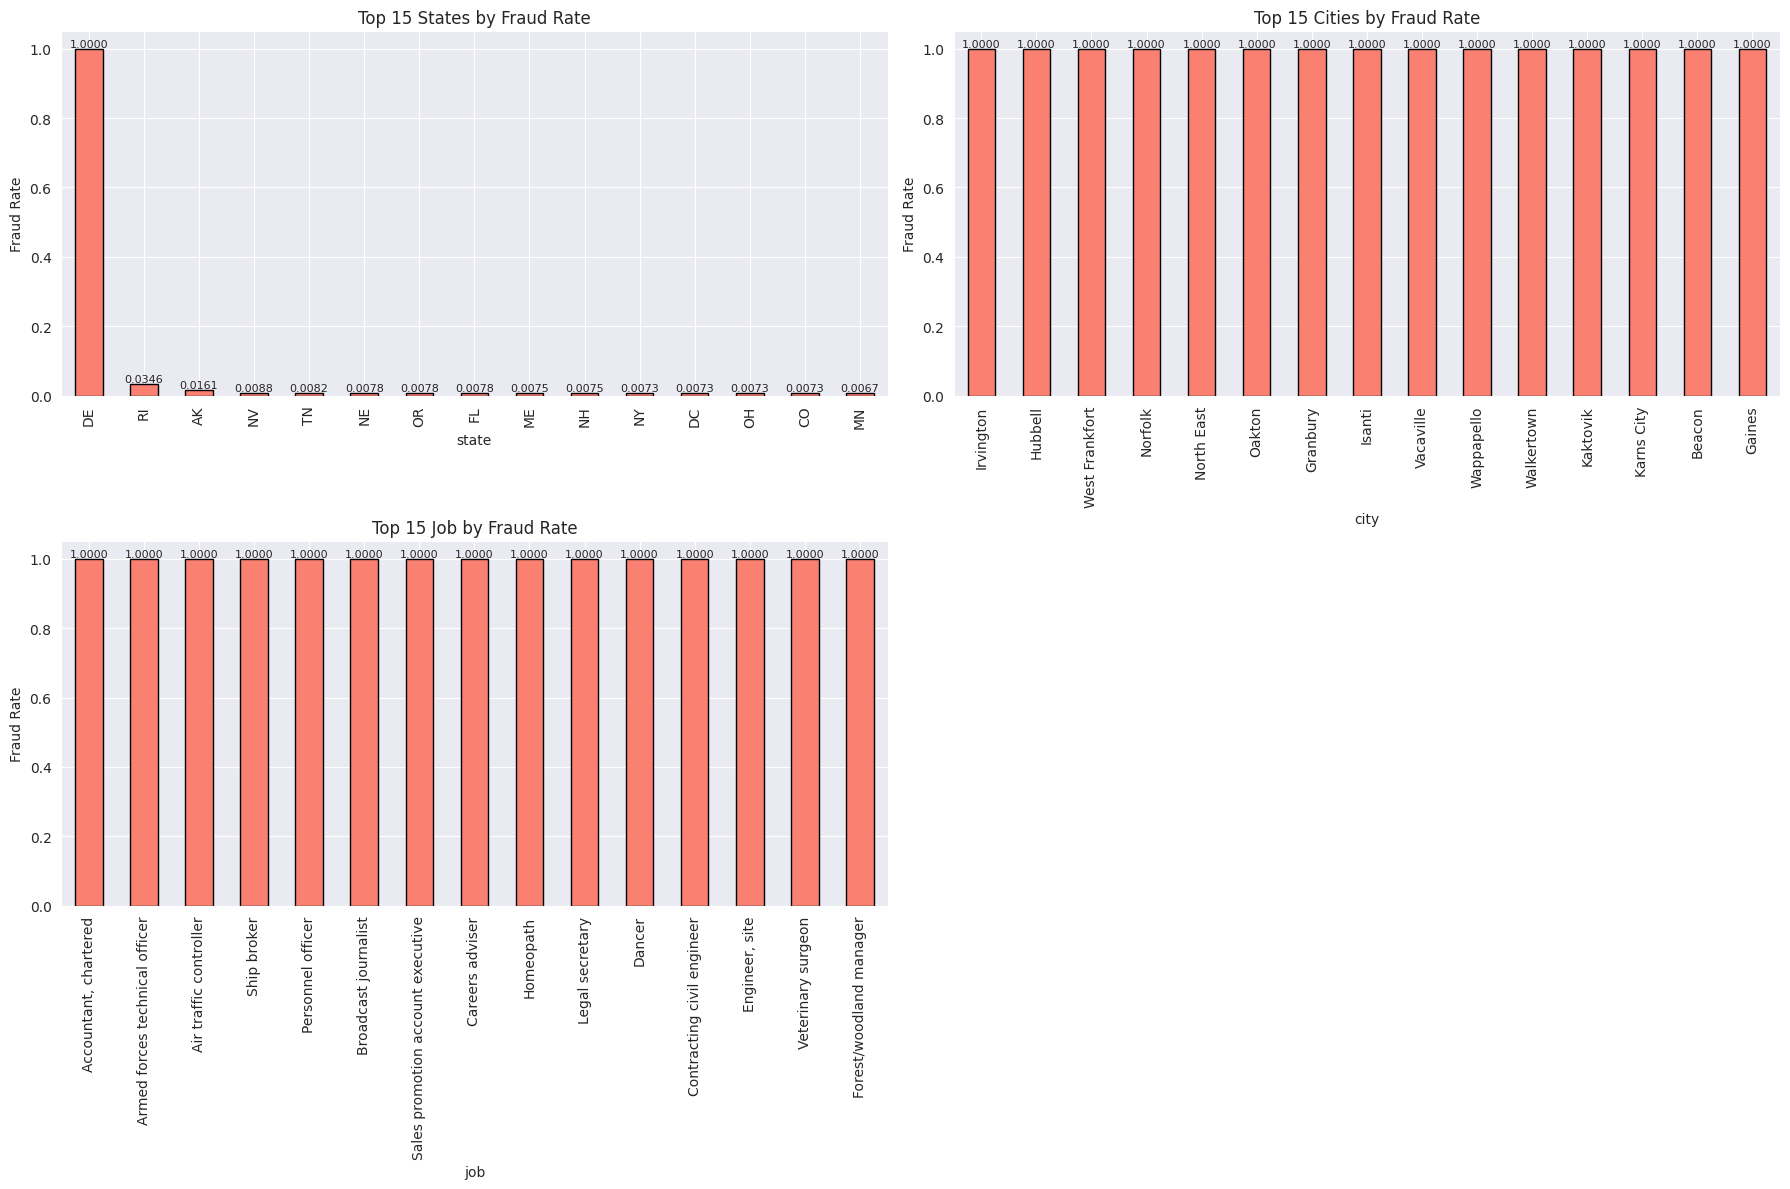

In [31]:
def plot_top_fraud_rate(ax, df, col, title, top_n=15):
    fraud_rate = df.groupby(col)['is_fraud'].mean().sort_values(ascending=False).head(top_n)
    
    
    # fraud_rate = fraud_rate[fraud_rate < 1.0].head(top_n)
    
    fraud_rate.plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=90)
    
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

fig, ax = plt.subplots(2, 2, figsize=(18, 12))
plot_top_fraud_rate(ax[0,0], df_train, 'state', 'Top 15 States by Fraud Rate')
plot_top_fraud_rate(ax[0,1], df_train, 'city',  'Top 15 Cities by Fraud Rate')
plot_top_fraud_rate(ax[1,0], df_train, 'job',  'Top 15 Job by Fraud Rate')
ax[1,1].set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
baseline = df_train['is_fraud'].mean()
job_stats = df_train.groupby('job').agg(
    total_txns=('is_fraud', 'count'),
    fraud_txns=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: x['fraud_txns'] / x['total_txns'],
         lift = lambda x:(x['fraud_txns'] / x['total_txns']) / baseline
).sort_values(by = 'fraud_rate', ascending = False)

job_stats.head(20)

,total_txns,fraud_txns,fraud_rate,lift
job,,,,
"Accountant, chartered",11,11,1.000000,173.731649
Armed forces technical officer,8,8,1.000000,173.731649
Air traffic controller,8,8,1.000000,173.731649
Ship broker,7,7,1.000000,173.731649
Personnel officer,12,12,1.000000,173.731649
Broadcast journalist,9,9,1.000000,173.731649
Sales promotion account executive,14,14,1.000000,173.731649
Careers adviser,15,15,1.000000,173.731649
Homeopath,11,11,1.000000,173.731649


## Handling High-Cardinality Features: `state`, `city`, `job`

### Problem
Raw fraud rates from small-sample groups are unreliable (e.g., a job with 9 transactions all fraud → 100% rate, but it's just noise).

### Solution: Threshold + Smoothing + Out-of-Fold

| Layer | Effect |
|---|---|
| **Threshold** (`min_samples=50`) | Groups with too few samples → use global mean |
| **Smoothing** (`k=100`) | Shrinks estimates toward global mean based on sample size |
| **Out-of-Fold** (`GroupKFold`, 5 folds, grouped by `cc_num`) | Each training row's encoded rate is computed excluding its own fold, preventing a row's own label from leaking into its own feature |

In [33]:
from sklearn.model_selection import GroupKFold
def target_encode_oof(train_df, val_df, test_df, cols, target='is_fraud',
                       n_splits=5, min_samples=50, smoothing=100):
    """
    Target encoding with minimum sample threshold and Bayesian smoothing.

    - Group count < `min_samples` → falls back to global mean.
    - Otherwise: smoothed rate = (n * group_mean + k * global_mean) / (n + k)

    `train_df` is encoded out-of-fold (GroupKFold on `cc_num`) to avoid a row
    leaking into its own rate. `val_df`/`test_df` are encoded using the rate
    fit on the full `train_df`. `train_df` must already be the pre-cutoff
    split before calling this — no val/test data is ever seen during fitting.
    Unseen categories fall back to the global mean.
    """
    train_df, val_df, test_df = train_df.copy(), val_df.copy(), test_df.copy()
    global_mean = train_df[target].mean()

    def smoothed_rate(frame, col):
        stats = frame.groupby(col)[target].agg(['mean', 'count'])
        rate = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        return rate.where(stats['count'] >= min_samples, global_mean)

    folds = list(GroupKFold(n_splits=n_splits).split(train_df, groups=train_df['cc_num']))

    for col in cols:
        new_col = col + '_fraud_rate'


        train_df[new_col] = np.nan
        for other_idx, this_idx in folds:
            rate = smoothed_rate(train_df.iloc[other_idx], col)
            train_df.iloc[this_idx, train_df.columns.get_loc(new_col)] = train_df.iloc[this_idx][col].map(rate).values


        full_train_rate = smoothed_rate(train_df, col)
        val_df[new_col]  = val_df[col].map(full_train_rate)
        test_df[new_col] = test_df[col].map(full_train_rate)

        train_df[new_col] = train_df[new_col].fillna(global_mean)
        val_df[new_col]   = val_df[new_col].fillna(global_mean)
        test_df[new_col]  = test_df[new_col].fillna(global_mean)

    return train_df.drop(columns=cols), val_df.drop(columns=cols), test_df.drop(columns=cols)

In [34]:
df_train, df_val, test = target_encode_oof(
    df_train, df_val, test,
    cols=['state', 'city', 'job'],
    min_samples=50,
    smoothing=100
)

In [35]:
df_train.sample(5)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,street,zip,lat,long,city_pop,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,Day,Month,Hour,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,amt_group,state_fraud_rate,city_fraud_rate,job_fraud_rate
969245,2019-06-28 14:58:16,4469777115158234880,fraud_Jewess LLC,shopping_pos,5.83,Gregory,Graham,4005 Dana Glens,1844,42.7280,-71.1810,47249,1980-11-22,41f83d459b0f891d5245de57055747ef,1340895496,43.432302,-71.788629,0,41,4,6,14,Adult,7331.0,1.0,5.83,31.853333,0.183026,0,Low,0.005492,0.005756,0.001086
709354,2019-02-27 02:30:48,4294040533480516,fraud_Cartwright-Harris,grocery_pos,101.21,Gail,Weaver,979 Stewart Lake,29809,33.4130,-81.6900,2206,1986-12-31,1918edc01f8fd6bfaf14b083ac2b0656,1330309848,33.354212,-81.109507,0,35,2,2,2,Adult,45602.0,1.0,101.21,51.630000,1.960294,1,Mid,0.004539,0.005756,0.005774
336833,2019-09-04 22:26:53,343746486082492,fraud_Kilback and Sons,entertainment,4.35,Jeffrey,Munoz,836 Stephanie Union,49621,44.8605,-85.8138,3096,1975-10-11,6a537fe600d8747c0ad9284b28bc67a8,1346797613,43.972713,-85.223617,0,46,2,9,22,Middle Age,82267.0,1.0,4.35,73.463333,0.059213,1,Low,0.005337,0.005756,0.005756
264264,2019-08-24 20:29:33,180049032966888,fraud_Homenick LLC,personal_care,76.68,Michael,Flores,70761 Fitzpatrick Brooks Suite 631,54559,46.4959,-90.4383,795,1986-04-15,a3a990fbdbe4533ffd2062ee01977696,1345840173,46.651652,-91.014807,0,35,5,8,20,Adult,4121.0,1.0,76.68,73.648333,1.041164,0,Low,0.006415,0.005756,0.014741
527686,2019-03-08 16:11:50,3528231451607350,fraud_Hilpert-Conroy,kids_pets,169.00,Lauren,Moreno,83719 Wilson Shore,8324,39.2240,-74.9942,526,1940-09-06,9f22d642c9d7bdee332dc179ce06a4c4,1331223110,39.233605,-74.257993,0,81,4,3,16,Elderly,94971.0,1.0,169.00,169.000000,1.000000,0,Mid,0.005244,0.005756,0.010644


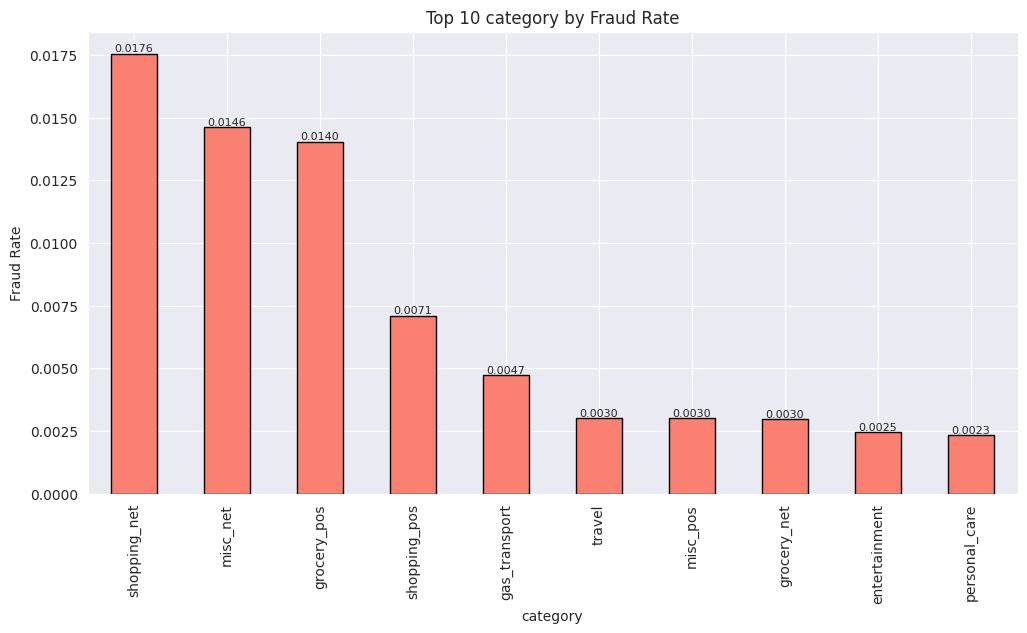

In [36]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_top_fraud_rate(ax, df_train, 'category', 'Top 10 category by Fraud Rate', top_n=10)
plt.show()

## Feature Engineering: `category`

The `category` feature can be enriched with **two derived features** that capture different aspects of fraud risk:

### 1. `is_online` — Transaction channel
Categories ending with `_net` are online transactions, while `_pos` indicates in-person (point-of-sale). Online transactions tend to have higher fraud rates because they lack physical verification.

```python
df['is_online'] = df['category'].str.endswith('_net').astype(int)
```

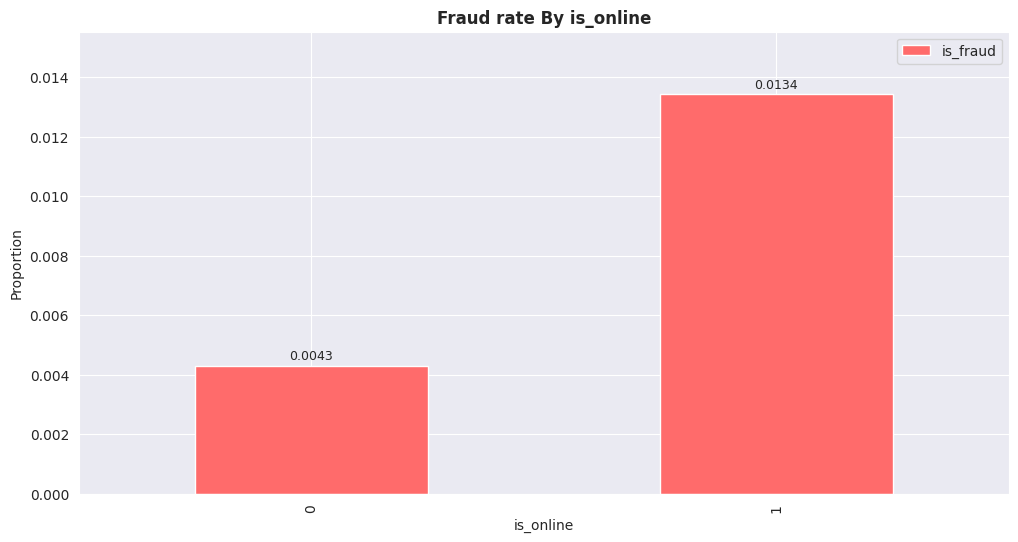

In [37]:
df_train['is_online'] = df_train['category'].str.endswith('_net').astype(int)
df_val['is_online']   = df_val['category'].str.endswith('_net').astype(int)
test['is_online']     = test['category'].str.endswith('_net').astype(int)

fig, ax = plt.subplots(figsize=(12, 6))
plot_fraud_rate(ax, df_train, 'is_online', 'Fraud rate By is_online')
plt.show()

### 2. `risk_tier` — Fraud risk level
Based on the fraud rate analysis, categories fall into three distinct tiers:

| Tier | Categories | Fraud Rate |
|------|-----------|------------|
| **High (2)** | `shopping_net`, `misc_net`, `grocery_pos` | 1.4% – 1.8% |
| **Mid (1)**  | `shopping_pos`, `gas_transport` | 0.5% – 0.7% |
| **Low (0)**  | Remaining categories | < 0.3% |

> ⚠️ Tier boundaries are derived from the **training set only** to avoid target leakage.

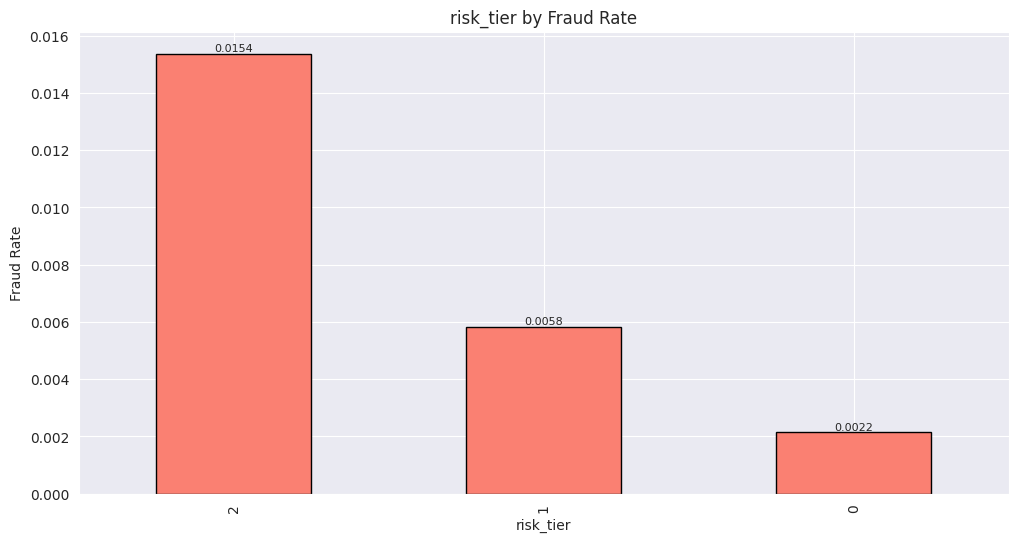

In [38]:
def risk_tier(cat):
    if cat in ['shopping_net', 'misc_net', 'grocery_pos']: return 2
    if cat in ['shopping_pos', 'gas_transport']: return 1
    return 0

df_train['risk_tier'] = df_train['category'].apply(risk_tier)
df_val['risk_tier']   = df_val['category'].apply(risk_tier)
test['risk_tier']     = test['category'].apply(risk_tier)

fig, ax = plt.subplots(figsize=(12, 6))
plot_top_fraud_rate(ax, df_train, 'risk_tier', 'risk_tier by Fraud Rate')
plt.show()

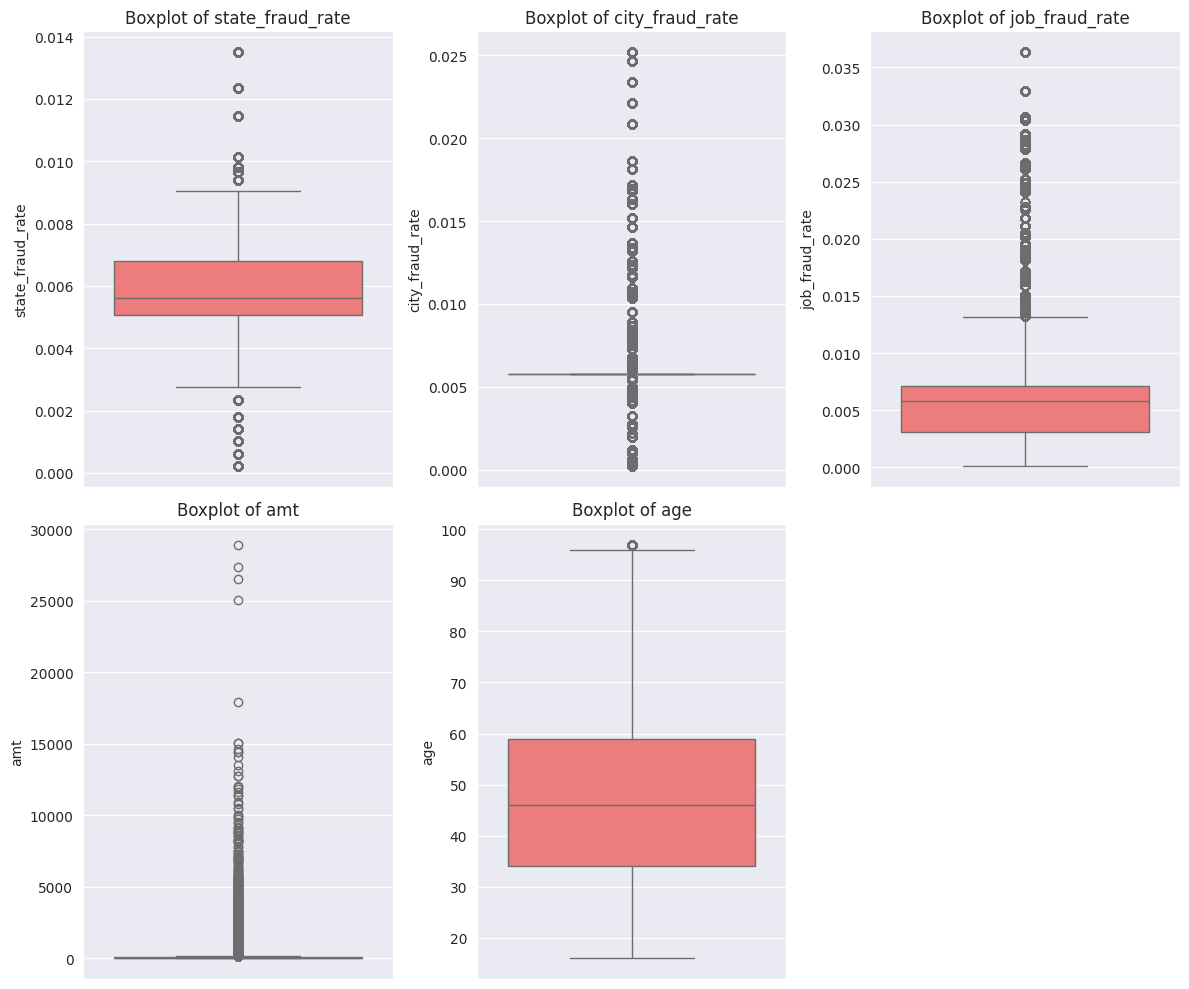

In [39]:
fig, ax = plt.subplots(2,3, figsize=(12,10))
sns.boxplot(data=df_train, y='state_fraud_rate', ax=ax[0,0])
ax[0,0].set_title('Boxplot of state_fraud_rate')
sns.boxplot(data=df_train, y='city_fraud_rate', ax=ax[0,1])
ax[0,1].set_title('Boxplot of city_fraud_rate')
sns.boxplot(data=df_train, y='job_fraud_rate', ax=ax[0,2])
ax[0,2].set_title('Boxplot of job_fraud_rate')
sns.boxplot(data=df_train, y='amt', ax=ax[1,0])
ax[1,0].set_title('Boxplot of amt')
sns.boxplot(data=df_train, y='age', ax=ax[1,1])
ax[1,1].set_title('Boxplot of age')
ax[1,2].set_visible(False)
plt.tight_layout()
plt.show()

In [40]:
def count_outliers_iqr(df, cols):
    """
    Count outliers for each column using IQR method.
    Outlier is defined as values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
    """
    results = []
    
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
        pct        = n_outliers / len(df) * 100
        
        results.append({
            'Feature'      : col,
            # 'Q1'           : round(Q1, 6),
            # 'Q3'           : round(Q3, 6),
            # 'IQR'          : round(IQR, 6),
            # 'Lower Bound'  : round(lower, 6),
            # 'Upper Bound'  : round(upper, 6),
            'N Outliers'   : n_outliers,
            'Outlier %'    : round(pct, 2)
        })
    
    return pd.DataFrame(results).set_index('Feature')


encoded_cols = ['state_fraud_rate', 'city_fraud_rate', 'job_fraud_rate', 'amt', 'age']
outlier_summary = count_outliers_iqr(df_train, encoded_cols)
print(outlier_summary)

                  N Outliers  Outlier %
Feature                                
state_fraud_rate       42898       4.19
city_fraud_rate       114181      11.14
job_fraud_rate         77615       7.57
amt                    53240       5.19
age                      440       0.04


In [41]:
def analyze_outliers_fraud(df, cols):
    """
    Check whether outliers are predominantly fraud or not fraud.
    """
    total_fraud = (df['is_fraud'].astype(int) == 1).sum()  
    results = []
    
    for col in cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        is_outlier    = (df[col] < lower) | (df[col] > upper)
        outlier_df    = df[is_outlier]
        
        fraud_in_outlier      = (outlier_df['is_fraud'].astype(int) == 1).sum()
        nonfraud_in_outlier   = (outlier_df['is_fraud'].astype(int) == 0).sum()
        fraud_rate_in_outlier = fraud_in_outlier / len(outlier_df) * 100
        pct_of_total_fraud    = fraud_in_outlier / total_fraud * 100  
        
        results.append({
            'Feature'                : col,
            'Total Outliers'         : len(outlier_df),
            'Fraud in Outliers'      : fraud_in_outlier,
            'NonFraud in Outliers'   : nonfraud_in_outlier,
            'Fraud Rate in Outlier %': round(fraud_rate_in_outlier, 2),
            '% of Total Fraud'       : round(pct_of_total_fraud, 2)   
        })
    
    return pd.DataFrame(results).set_index('Feature')

print(analyze_outliers_fraud(df_train, encoded_cols))

                  Total Outliers  Fraud in Outliers  NonFraud in Outliers  \
Feature                                                                     
state_fraud_rate           42898                207                 42691   
city_fraud_rate           114181                728                113453   
job_fraud_rate             77615                375                 77240   
amt                        53240               4474                 48766   
age                          440                  0                   440   

                  Fraud Rate in Outlier %  % of Total Fraud  
Feature                                                      
state_fraud_rate                     0.48              3.51  
city_fraud_rate                      0.64             12.34  
job_fraud_rate                       0.48              6.36  
amt                                  8.40             75.84  
age                                  0.00              0.00  


**Key insight:** The majority of fraud cases live in the outlier regions — most notably, **76% of all fraud occurs in the outlier region of `amt`**.

This means outliers are **not noise — they are the signal**. Dropping them would destroy the model's ability to detect fraud.


### Scaling Strategy

Since we cannot drop these outliers, we apply transformations that **preserve their ordering** while reducing their numerical influence on scale-sensitive models:

1. **`log1p`** — Applied to skewed features (e.g., `amt`) to compress the scale without losing rank information.
2. **`RobustScaler`** — Uses median and IQR instead of mean and standard deviation, making it resistant to extreme values.

In [42]:
from sklearn.preprocessing import RobustScaler
def scale_features(train_df, val_df, test_df, log_cols=None, scale_cols=None):
    """
    Apply log1p + RobustScaler to numerical features.

    Pipeline:
    1. For columns in `log_cols`: apply log1p (compress skewed distributions).
    2. For all columns in `log_cols` + `scale_cols`: apply RobustScaler
       (rescale using median and IQR; resistant to outliers).
    """
    # ---- Step 1: log1p ----
    for col in log_cols:
        for d in (train_df, val_df, test_df):
            if (d[col] < 0).any():
                raise ValueError(f"Column '{col}' contains negative values; log1p requires x >= -1.")
            d[col] = np.log1p(d[col])

    # ---- Step 2: RobustScaler (fit on train only) ----
    all_cols = log_cols + scale_cols
    scaler = RobustScaler()
    train_df[all_cols] = scaler.fit_transform(train_df[all_cols])
    val_df[all_cols]   = scaler.transform(val_df[all_cols])
    test_df[all_cols]  = scaler.transform(test_df[all_cols])

    return train_df, val_df, test_df

df_train, df_val, test = scale_features(
    df_train, df_val, test,
    log_cols=['amt'],
    scale_cols=['state_fraud_rate', 'city_fraud_rate', 'job_fraud_rate', 'age'],
)

In [43]:
encoded_cols = ['state_fraud_rate', 'city_fraud_rate', 'job_fraud_rate', 'amt', 'age']

summary = df_train.groupby('is_fraud')[encoded_cols].mean().T
summary.columns = ['Not Fraud', 'Fraud']
summary['diff'] = summary['Fraud'] - summary['Not Fraud']
print(summary.sort_values('diff', ascending=False))

                  Not Fraud     Fraud      diff
amt               -0.174039  0.814820  0.988859
age                0.070234  0.172578  0.102345
city_fraud_rate    0.000149  0.000156  0.000007
job_fraud_rate     0.126988  0.066738 -0.060250
state_fraud_rate   0.181769  0.110832 -0.070938


**Key takeaways**
- `amt` shows by far the strongest separation (~0.99 apart), consistent with fraud being concentrated in its outlier region.
- `age` shows the second-strongest separation (diff ≈ 0.10) — moderate, but the highest among the non-`amt` features.
- `city_fraud_rate` shows essentially no separation (diff ≈ 0.000007) and contributes little predictive power on its own.
- `job_fraud_rate` and `state_fraud_rate` show weak, slightly negative separation (diff ≈ -0.06 and -0.07) — fraud transactions have marginally *lower* average rate than non-fraud on these features, and both remain low-value predictors on their own.

In [44]:
drop_encode_feat = ['city_fraud_rate', 'job_fraud_rate', 'state_fraud_rate']

for d in (df_train, df_val, test):
    d.drop(columns=drop_encode_feat, inplace=True)

In [45]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,street,zip,lat,long,city_pop,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,Day,Month,Hour,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,amt_group,is_online,risk_tier
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,-0.855332,Mary,Diaz,9886 Anita Drive,82514,43.0048,-108.8964,1645,1986-02-17,98e3dcf98101146a577f85a34e58feec,1325422035,43.974711,-109.741904,0,-0.44,1,1,12,Adult,999999.0,1.0,7.27,7.2700,1.000000,0,Low,1,2
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,0.052038,Mary,Diaz,9886 Anita Drive,82514,43.0048,-108.8964,1645,1986-02-17,498120fc45d277f7c88e3dba79c33865,1325493897,42.018766,-109.044172,0,-0.44,2,1,8,Adult,71862.0,1.0,52.94,30.1050,1.758512,0,Low,0,1
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,0.261037,Mary,Diaz,9886 Anita Drive,82514,43.0048,-108.8964,1645,1986-02-17,95f514bb993151347c7acdf8505c3d62,1325494056,42.961335,-109.157564,0,-0.44,2,1,8,Adult,159.0,2.0,135.02,47.4300,1.730550,0,Low,0,1
3,2019-01-02 12:38:14,60416207185,fraud_Daugherty LLC,kids_pets,-0.146447,Mary,Diaz,9886 Anita Drive,82514,43.0048,-108.8964,1645,1986-02-17,4f0c1a14e0aa7eb56a490780ef9268c5,1325507894,42.228227,-108.747683,0,-0.44,2,1,12,Adult,13838.0,1.0,34.79,44.2700,0.785859,0,Low,0,0
4,2019-01-02 13:10:46,60416207185,fraud_Beier and Sons,home,-0.262119,Mary,Diaz,9886 Anita Drive,82514,43.0048,-108.8964,1645,1986-02-17,3b2ebd3af508afba959640893e1e82bc,1325509846,43.321745,-108.091143,0,-0.44,2,1,13,Adult,1952.0,2.0,61.97,49.2475,0.551906,0,Low,0,0


In [46]:
from math import radians

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df_train['distance_km'] = haversine_distance(df_train['lat'], df_train['long'], df_train['merch_lat'], df_train['merch_long'])
df_val['distance_km']   = haversine_distance(df_val['lat'],   df_val['long'],   df_val['merch_lat'],   df_val['merch_long'])
test['distance_km']     = haversine_distance(test['lat'],     test['long'],     test['merch_lat'],     test['merch_long'])

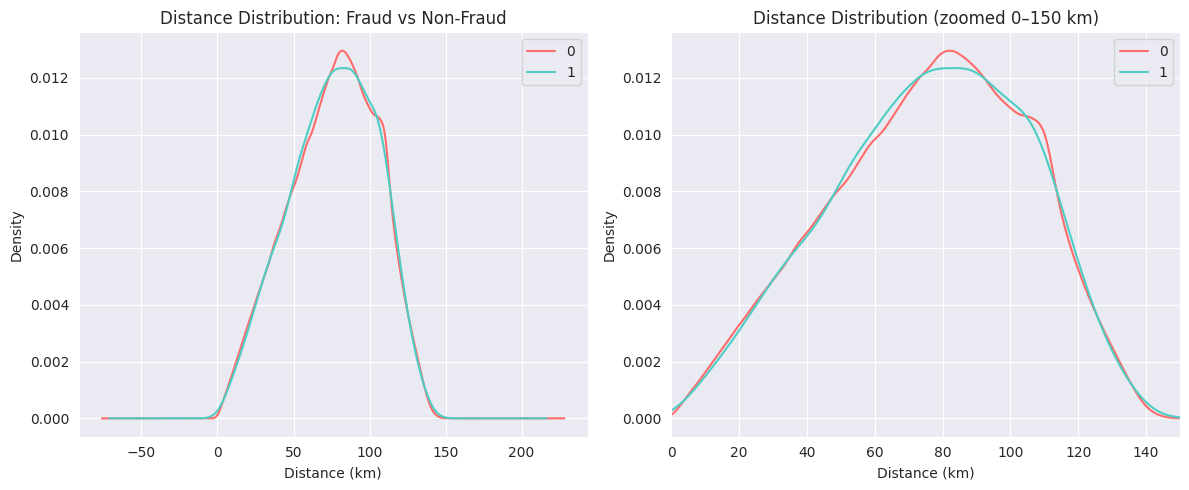

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

df_train.groupby('is_fraud')['distance_km'].plot(
    kind='kde', legend=True, ax=ax[0]
)
ax[0].set_title('Distance Distribution: Fraud vs Non-Fraud')
ax[0].set_xlabel('Distance (km)')

# Zoomed view (ตัด outlier ออกเพื่อดู pattern หลัก)
df_train.groupby('is_fraud')['distance_km'].plot(
    kind='kde', legend=True, ax=ax[1]
)
ax[1].set_xlim(0, 150)
ax[1].set_title('Distance Distribution (zoomed 0–150 km)')
ax[1].set_xlabel('Distance (km)')

plt.tight_layout()
plt.show()

In [48]:
df_train['distance_bin'] = pd.cut(df_train['distance_km'], 
                              bins=[0, 25, 50, 75, 100, 150, 1000],
                              labels=['0-25', '25-50', '50-75', '75-100', '100-150', '150+'])

fraud_by_dist = df_train.groupby('distance_bin', observed=True)['is_fraud'].mean()
print(fraud_by_dist)

distance_bin
0-25       0.005301
25-50      0.005675
50-75      0.005972
75-100     0.005722
100-150    0.005717
150+       0.000000
Name: is_fraud, dtype: float64


## Feature Decision: `distance`

The distance distributions for Fraud and Not Fraud are **nearly identical** — both classes peak around 80–90 km with virtually overlapping KDE curves, even in the zoomed view (0–150 km).

**Decision: Drop `distance` from the feature set.**

Including it would only add noise and dimensionality without contributing predictive power.

In [49]:
df_train.drop(['distance_bin', 'distance_km'], axis=1, inplace=True)
df_val.drop(['distance_km'], axis=1, inplace=True)   
test.drop(['distance_km'], axis=1, inplace=True)

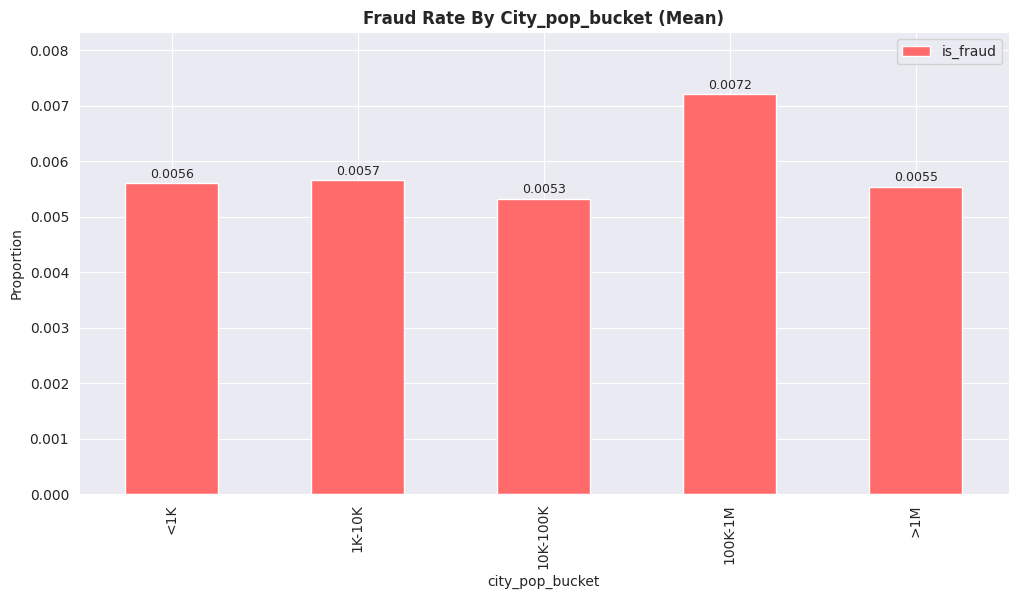

In [50]:
df_train['city_pop_bucket'] = pd.cut(
    df_train['city_pop'],
    bins=[0, 1_000, 10_000, 100_000, 1_000_000, df['city_pop'].max()],
    labels=['<1K', '1K-10K', '10K-100K', '100K-1M', '>1M']
)

fig, ax = plt.subplots(figsize= (12,6))
plot_fraud_rate(ax, df_train, 'city_pop_bucket', 'Fraud Rate By City_pop_bucket (Mean)')
plt.show()

All buckets sit within a narrow range of 0.55%–0.67%, with a max-to-min ratio of only 1.22x. The slight elevation in the 100K–1M bucket is too small to be meaningful, and overall the feature shows **no clear monotonic or categorical pattern** related to fraud.

**Decision: Drop `city_pop` from the feature set.**

In [51]:
df_train.drop(['city_pop', 'city_pop_bucket'], axis=1, inplace=True)
df_val.drop(['city_pop'], axis=1, inplace=True)
test.drop(['city_pop'], axis=1, inplace=True)

In [52]:
df_train[df_train['merchant'].str[0:6] != 'fraud_'].shape[0]

0

Every merchant name starts with 'fraud_'. We need to clean it.

In [53]:
df_train['merchant'] = df_train['merchant'].str[6:]
df_val['merchant']   = df_val['merchant'].str[6:]
test['merchant']     = test['merchant'].str[6:]

In [54]:
len(df_train['merchant'].unique())

693

In [55]:
baseline = df_train['is_fraud'].mean()
merchant_stats = df_train.groupby('merchant').agg(
    total_txns=('is_fraud', 'count'),
    fraud_txns=('is_fraud', 'sum')
).assign(fraud_rate=lambda x: x['fraud_txns'] / x['total_txns'],
         lift = lambda x:(x['fraud_txns'] / x['total_txns']) / baseline
).sort_values(by = 'fraud_rate', ascending = False)

merchant_stats.head(20)

,total_txns,fraud_txns,fraud_rate,lift
merchant,,,,
"Herman, Treutel and Dickens",1005,28,0.027861,4.840285
Kozey-Boehm,1485,37,0.024916,4.328667
Goyette Inc,1558,34,0.021823,3.791320
Boyer-Reichert,1517,33,0.021753,3.779265
Terry-Huel,1569,34,0.021670,3.764739
"Towne, Greenholt and Koepp",1537,33,0.021470,3.730087
Fisher-Schowalter,1538,33,0.021456,3.727662
Gleason-Macejkovic,1601,34,0.021237,3.689492
Kuhic LLC,1561,33,0.021140,3.672738


In [56]:
tiers = {
    'Top 1-30':    merchant_stats.iloc[:30],
    'Top 31-50':   merchant_stats.iloc[30:50],
    'Top 51-100':  merchant_stats.iloc[50:100],
    'Top 101-300': merchant_stats.iloc[100:300],
    'Rest':        merchant_stats.iloc[300:],
}

baseline = df_train['is_fraud'].mean()
for name, group in tiers.items():
    mean_rate = group['fraud_rate'].mean()
    lift = mean_rate / baseline
    print(f"{name:14s} → mean rate: {mean_rate:.4f}, lift: {lift:.2f}x, n={len(group)}")

Top 1-30       → mean rate: 0.0206, lift: 3.57x, n=30
Top 31-50      → mean rate: 0.0173, lift: 3.01x, n=20
Top 51-100     → mean rate: 0.0148, lift: 2.57x, n=50
Top 101-300    → mean rate: 0.0072, lift: 1.25x, n=200
Rest           → mean rate: 0.0019, lift: 0.32x, n=393


In [57]:
df_train, df_val, test = target_encode_oof(
    df_train, df_val, test,
    cols=['merchant'],
    min_samples=50,
    smoothing=100
)

In [58]:
df_train.sample()

,trans_date_trans_time,cc_num,category,amt,first,last,street,zip,lat,long,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,Day,Month,Hour,age_group,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,amt_group,is_online,risk_tier,merchant_fraud_rate
83327,2019-02-04 19:09:38,4158008602445,food_dining,-0.443265,Alicia,Miller,976 Hubbard Lodge,55065,44.5274,-93.0196,1979-12-27,752b59a63ee0f58c804a280a2d5d14ed,1328382578,44.4931,-92.931796,0,-0.16,0,2,19,Adult,74378.0,1.0,18.38,48.84,0.376331,0,Low,0,0,0.001168


In [59]:
def encode_category_and_age(train_df, val_df, test_df):
    """
    One-hot encode `category` and `age_group` using pd.get_dummies.
    
    After encoding, test columns are aligned to train columns to ensure
    consistency — any unseen categories in test are dropped, and missing
    categories are filled with 0.
    """
    train_df = train_df.copy()
    val_df   = val_df.copy()
    test_df  = test_df.copy()

    cols = ['category', 'age_group', 'amt_group']

    train_df = pd.get_dummies(train_df, columns=cols, prefix=cols, dtype=int, drop_first=True)
    val_df   = pd.get_dummies(val_df,   columns=cols, prefix=cols, dtype=int, drop_first=True)
    test_df  = pd.get_dummies(test_df,  columns=cols, prefix=cols, dtype=int, drop_first=True)


    val_df  = val_df.reindex(columns=train_df.columns, fill_value=0)
    test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

    return train_df, val_df, test_df

In [60]:
df_train, df_val, test = encode_category_and_age(df_train, df_val, test)

In [61]:
cols_to_drop = ['lat', 'long', 'merch_lat', 'merch_long', 
                'cc_num', 'street', 'unix_time',
                'trans_num', 'last', 'first', 'zip', 'dob']
df_train.drop(columns=cols_to_drop, inplace=True)
df_val.drop(columns=cols_to_drop, inplace=True)
test.drop(columns=cols_to_drop, inplace=True)

In [62]:
df_train.sample()

,trans_date_trans_time,amt,is_fraud,age,Day,Month,Hour,time_since_last,txn_count_1h,amt_sum_1h,amt_mean_24h,amt_vs_mean_24h,is_night,is_online,risk_tier,merchant_fraud_rate,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_Young Adult,age_group_Adult,age_group_Middle Age,age_group_Senior,age_group_Elderly,amt_group_Mid,amt_group_High
901793,2019-10-29 16:32:08,0.09485,0,1.16,1,10,16,114568.0,1.0,57.93,57.93,1.0,0,0,0,0.00275,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [63]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# --- Split features and target ---
feature_cols = [c for c in df_train.columns if c not in ('is_fraud', 'trans_date_trans_time')]

X_train = df_train[feature_cols]
y_train = df_train['is_fraud']
X_val   = df_val[feature_cols]
y_val   = df_val['is_fraud']

X_test = test[feature_cols]
y_test = test['is_fraud']

# --- Strategy 1: Original (no resampling) ---
X_train_orig, y_train_orig = X_train.copy(), y_train.copy()
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# --- Strategy 2: Random Undersampling ---
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

# --- Strategy 3: SMOTE Oversampling ---
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

In [64]:
print("="*60)
print("Sampling Strategy Summary")
print("="*60)

for name, X, y in [
    ('Original',     X_train_orig,  y_train_orig),
    ('Undersampled', X_train_under, y_train_under),
    ('Oversampled',  X_train_over,  y_train_over),
]:
    n_fraud    = (y == 1).sum()
    n_nonfraud = (y == 0).sum()
    print(f"\n{name}:")
    print(f"  Shape:        {X.shape}")
    print(f"  Not Fraud:    {n_nonfraud:>10,}")
    print(f"  Fraud:        {n_fraud:>10,}")
    print(f"  Fraud rate:   {y.mean():.4f}")

print(f"\nscale_pos_weight (for Strategy 1): {scale_pos_weight:.2f}")
print(f"\nTest set (never resampled): {X_test.shape}, fraud rate: {y_test.mean():.4f}")

Sampling Strategy Summary

Original:
  Shape:        (1024843, 34)
  Not Fraud:     1,018,944
  Fraud:             5,899
  Fraud rate:   0.0058

Undersampled:
  Shape:        (11798, 34)
  Not Fraud:         5,899
  Fraud:             5,899
  Fraud rate:   0.5000

Oversampled:
  Shape:        (2037888, 34)
  Not Fraud:     1,018,944
  Fraud:         1,018,944
  Fraud rate:   0.5000

scale_pos_weight (for Strategy 1): 172.73

Test set (never resampled): (555719, 34), fraud rate: 0.0039


In [65]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    PrecisionRecallDisplay,
)

logreg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver='lbfgs',
        n_jobs=-1,
    )),
])


models = {
    # 'Logistic Regression': logreg_pipeline,

    # 'Decision Tree': DecisionTreeClassifier(
    #     max_depth=20,          
    #     min_samples_leaf=5,    
    #     random_state=42,
    # ),

    # 'Random Forest': RandomForestClassifier(
    #     n_estimators=300,                    
    #     max_depth=None,                      
    #     min_samples_leaf=2,
    #     max_samples=0.5,
    #     class_weight='balanced_subsample',   
    #     random_state=42,
    #     n_jobs=-1,
    #  ),

    'XGBoost': XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=1,     
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='aucpr',
    ),

    # 'LightGBM': LGBMClassifier(
    #     n_estimators=500,
    #     learning_rate=0.05,
    #     num_leaves=63,
    #     min_child_samples=5,    
    #     subsample=0.8,
    #     colsample_bytree=0.8,
    #     random_state=42,
    #     n_jobs=-1,
    #     verbose=-1,
    # ),
}

In [66]:
def _set_imbalance_param(model, value, balanced=False):
    """Helper: set scale_pos_weight or class_weight based on model type."""
    # Handle Pipeline (LogReg wrapped in scaler)
    target = model.named_steps['clf'] if isinstance(model, Pipeline) else model
    params = target.get_params()
    
    if 'scale_pos_weight' in params:
        target.set_params(scale_pos_weight=value)
    elif 'class_weight' in params:
        target.set_params(class_weight='balanced' if balanced else None)


def train_strategies(model):
    """
    Train a model across all 3 sampling strategies.
    
    - Original strategy uses class_weight='balanced' or scale_pos_weight
    - Resampled strategies use no imbalance correction (data already balanced)
    """
    datasets = [
        ('Original',     X_train_orig,  y_train_orig,  True),
        ('Undersampled', X_train_under, y_train_under, False),
        ('Oversampled',  X_train_over,  y_train_over,  False),
    ]
    
    trained = {}
    for name, X, y, use_imbalance in datasets:
        print(f"  {name:>13s}  |  n={len(X):>10,}  |  fraud_rate={y.mean():.4f}")
        
        m = clone(model)
        
        if use_imbalance:
            _set_imbalance_param(m, scale_pos_weight, balanced=True)
        else:
            _set_imbalance_param(m, 1, balanced=False)
        
        m.fit(X, y)
        trained[name] = m
    
    return trained


def train_all_models(models_dict):
    """Train every model across every sampling strategy."""
    all_trained = {}
    for model_name, model in models_dict.items():
        print(f"\n{'='*70}")
        print(f"Model: {model_name}")
        print('='*70)
        all_trained[model_name] = train_strategies(model)
    return all_trained

In [67]:
# Train all models across all strategies
all_trained = train_all_models(models)


Model: XGBoost
       Original  |  n= 1,024,843  |  fraud_rate=0.0058
   Undersampled  |  n=    11,798  |  fraud_rate=0.5000
    Oversampled  |  n= 2,037,888  |  fraud_rate=0.5000


In [68]:
def evaluate_strategies(trained_models, model_name='Model', threshold=0.5):
    """
    Evaluate trained models across sampling strategies.
    Shows PR-AUC, classification report, and overlaid PR curves.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    results = {}
    
    for name, model in trained_models.items():
        y_prob = model.predict_proba(X_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        
        auc_pr = average_precision_score(y_val, y_prob)
        results[name] = auc_pr
        
        print(f"\n{'-'*60}")
        print(f"{model_name} | {name} | PR-AUC: {auc_pr:.4f} | threshold: {threshold}")
        print('-'*60)
        print(classification_report(y_val, y_pred,
                                     target_names=['Not Fraud', 'Fraud']))
        
        PrecisionRecallDisplay.from_predictions(
            y_val, y_prob, name=f"{name} (AUC={auc_pr:.4f})", ax=ax
        )
    
    ax.set_title(f'PR Curve — {model_name}')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return results


def evaluate_all_models(all_trained, threshold=0.5):
    """
    Evaluate every model + strategy, then summarize as a grid.
    Returns DataFrame: rows=models, columns=strategies, values=PR-AUC.
    """
    summary = {}
    for model_name, trained_dict in all_trained.items():
        print(f"\n{'#'*70}")
        print(f"# {model_name}")
        print('#'*70)
        summary[model_name] = evaluate_strategies(trained_dict, model_name, threshold)
    
    summary_df = pd.DataFrame(summary).T
    summary_df.index.name = 'Model'
    summary_df.columns.name = 'Strategy'
    
    print(f"\n{'='*70}")
    print("Final Summary — PR-AUC")
    print('='*70)
    print(summary_df.round(4).to_string())
    
    best_model, best_strategy = summary_df.stack().idxmax()
    best_score = summary_df.stack().max()
    print(f"\n🏆 Best: {best_model} + {best_strategy} → PR-AUC = {best_score:.4f}")
    
    return summary_df


######################################################################
# XGBoost
######################################################################

------------------------------------------------------------
XGBoost | Original | PR-AUC: 0.9777 | threshold: 0.5
------------------------------------------------------------
              precision    recall  f1-score   support

   Not Fraud       1.00      1.00      1.00    270225
       Fraud       0.87      0.96      0.91      1607

    accuracy                           1.00    271832
   macro avg       0.93      0.98      0.95    271832
weighted avg       1.00      1.00      1.00    271832


------------------------------------------------------------
XGBoost | Undersampled | PR-AUC: 0.9372 | threshold: 0.5
------------------------------------------------------------
              precision    recall  f1-score   support

   Not Fraud       1.00      0.99      0.99    270225
       Fraud       0.30      0.99      0.47      1607



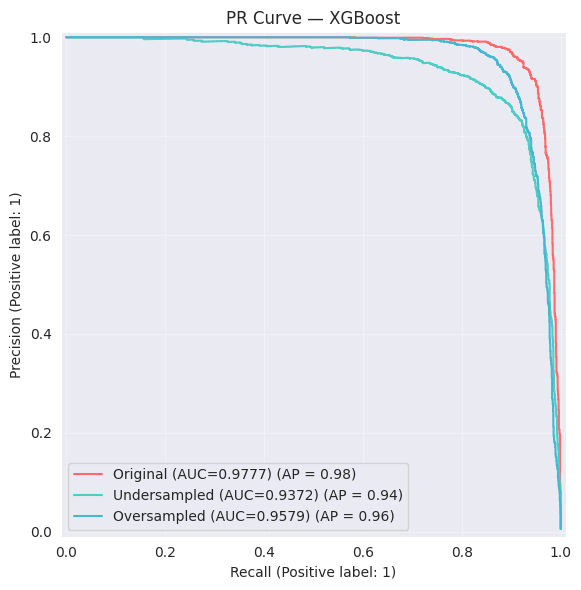


Final Summary — PR-AUC
Strategy  Original  Undersampled  Oversampled
Model                                        
XGBoost     0.9777        0.9372       0.9579

🏆 Best: XGBoost + Original → PR-AUC = 0.9777


In [69]:
# Evaluate and compare
summary_df = evaluate_all_models(all_trained, threshold=0.5)

## Classification Report — Fraud Class Only (threshold = 0.5)

| Model | Strategy | PR-AUC | Precision | Recall | F1-score |
|---|---|---|---|---|---|
| Logistic Regression | Original | 0.4038 | 0.11 | 0.96 | 0.19 |
| Logistic Regression | Undersampled | 0.3998 | 0.11 | 0.96 | 0.19 |
| Logistic Regression | Oversampled | 0.3756 | 0.22 | 0.80 | 0.34 |
| Decision Tree | Original | 0.8219 | 0.57 | 0.89 | 0.70 |
| Decision Tree | Undersampled | 0.2873 | 0.18 | 0.98 | 0.31 |
| Decision Tree | Oversampled | 0.1888 | 0.24 | 0.88 | 0.37 |
| **Random Forest** | **Original** | **0.9615** | **0.95** | 0.87 | 0.91 |
| Random Forest | Undersampled | 0.8913 | 0.25 | 0.98 | 0.39 |
| Random Forest | Oversampled | 0.9382 | 0.85 | 0.91 | 0.88 |
| **XGBoost** | **Original** | **0.9750** | 0.89 | 0.95 | **0.92** |
| XGBoost | Undersampled | 0.9318 | 0.31 | **0.99** | 0.48 |
| XGBoost | Oversampled | 0.9365 | 0.72 | 0.92 | 0.81 |
| **LightGBM** | **Original** | **0.9748** | 0.88 | 0.95 | **0.92** |
| LightGBM | Undersampled | 0.9394 | 0.34 | **0.99** | 0.50 |
| LightGBM | Oversampled | 0.9459 | 0.78 | 0.92 | 0.85 |

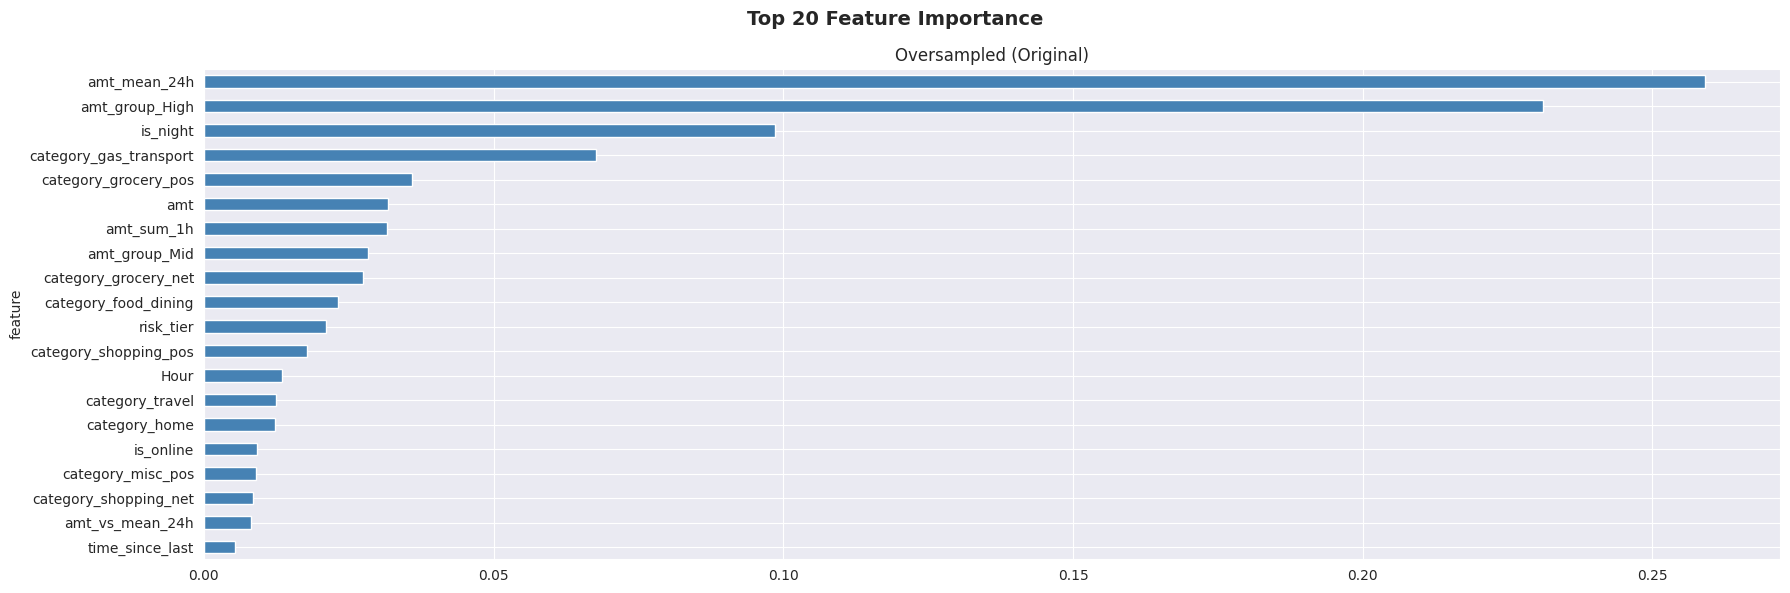

In [70]:
fig, ax = plt.subplots(figsize=(18, 6))

model = all_trained['XGBoost']['Original']
imp = model.feature_importances_
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': imp / imp.sum()
}).sort_values('importance', ascending=False)

importance_df.head(20).plot(kind='barh', x='feature', y='importance',
                              ax=ax, color='steelblue', legend=False)
ax.invert_yaxis()
ax.set_title(f'{name} (Original)')

fig.suptitle('Top 20 Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
# models_to_plot = [
#     # ('Random Forest', all_trained['Random Forest']['Original']),
#     ('XGBoost',        all_trained['XGBoost']['Original'])
#     # ('LightGBM',       all_trained['LightGBM']['Original']),
# ]

# fig, ax = plt.subplots(1, len(models_to_plot), figsize=(18, 6))

# for i, (name, model) in enumerate(models_to_plot):
#     imp = model.feature_importances_ if name != 'LightGBM' else model.booster_.feature_importance(importance_type='gain')
#     importance_df = pd.DataFrame({
#         'feature': X_train.columns,
#         'importance': imp / imp.sum()
#     }).sort_values('importance', ascending=False)

#     importance_df.head(20).plot(kind='barh', x='feature', y='importance',
#                                   ax=ax[i], color='steelblue', legend=False)
#     ax[i].invert_yaxis()
#     ax[i].set_title(f'{name} (Original)')

# fig.suptitle('Top 20 Feature Importance', fontsize=14, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [72]:
def find_thresholds_multi(precisions, recalls, thresholds, min_recall = 0.5, min_precision=0.5, target_precision= 0.99):

    f1_scores = 2 * (precisions * recalls) /(precisions + recalls + 1e-10)
    results = {}
    
    #F1-optimal
    idx = np.argmax(f1_scores[:-1])
    results['F1-optimal'] = {
        'threshold' : thresholds[idx], 
        'precision' : precisions[idx],
        'recall' : recalls[idx],
        'f1' : f1_scores[idx]
    }
    p, r, t = precisions[:-1], recalls[:-1], thresholds
    #Precision-optiaml
    mask = (p >= target_precision) & (r > 0)   # กันมุมประหลาด recall=0 ด้วย
    if mask.any():
        valid_idx = np.where(mask)[0]
        idx = valid_idx[np.argmax(r[valid_idx])]
        results['Precision-optimal'] = {
            'threshold': t[idx],
            'precision': p[idx],
            'recall':    r[idx],
            'f1':        f1_scores[idx],
        }
    else:
        results['Precision-optimal'] = None

    # 3) Recall-optimal 
    mask = precisions[:-1] >= min_precision
    if mask.any():
        valid_idx = np.where(mask)[0]
        idx = valid_idx[np.argmax(recalls[valid_idx])]
        results['Recall-optimal'] = {
            'threshold': thresholds[idx], 'precision': precisions[idx],
            'recall': recalls[idx], 'f1': f1_scores[idx],
        }
    else:
        results['Recall-optimal'] = None

    return results

In [73]:
from sklearn.metrics import precision_recall_curve
models_to_tuning = [
    ('XGBoost',       all_trained['XGBoost']['Original'])
]

curve_data = {}
for name, model in models_to_tuning:
    y_prob = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)
    curve_data[name] = {
        'y_prob': y_prob,
        'precisions': precisions,
        'recalls': recalls,
        'thresholds': thresholds,
        'ap': average_precision_score(y_val, y_prob),
    }

rows = []
for name, data in curve_data.items():
    multi = find_thresholds_multi(
        data['precisions'], data['recalls'], data['thresholds'],
        min_recall=0.5, min_precision=0.5
    )
    for metric_name, res in multi.items():
        if res is None:
            rows.append({'Model': name, 'Optimize for': metric_name,
                         'threshold': None, 'Precision': None, 'Recall': None, 'F1': None})
        else:
            rows.append({
                'Model': name, 'Optimize for': metric_name,
                'threshold': round(res['threshold'], 3),
                'Precision': round(res['precision'], 3),
                'Recall': round(res['recall'], 3),
                'F1': round(res['f1'], 3),
            })
multi_df = pd.DataFrame(rows).set_index(['Model', 'Optimize for'])
print(multi_df.to_string())

                           threshold  Precision  Recall     F1
Model   Optimize for                                          
XGBoost F1-optimal             0.907      0.951   0.924  0.937
        Precision-optimal      0.992      0.991   0.852  0.916
        Recall-optimal         0.014      0.500   0.987  0.664


In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
LOCKED_THRESHOLDS = {
    'F1-optimal':        0.907,
    'Precision-optimal': 0.992,
    'Recall-optimal':    0.014,
}


final_model = all_trained['XGBoost']['Original']
y_prob = final_model.predict_proba(X_test)[:, 1]

rows = []

for name, threshold in LOCKED_THRESHOLDS.items():
    y_pred = (y_prob >= threshold).astype(int)
    rows.append(
        {
        'Scenario':    name,
        'Threshold':   threshold,
        'Precision':   precision_score(y_test, y_pred),
        'Recall':      recall_score(y_test, y_pred),
        'F1':          f1_score(y_test, y_pred),
        'Flagged':     y_pred.sum(),                  
        'Flagged/day': round(y_pred.sum() / 193, 1),
        }
    )

final_results = pd.DataFrame(rows).set_index('Scenario')
print(final_results.round(3))

                   Threshold  Precision  Recall     F1  Flagged  Flagged/day
Scenario                                                                    
F1-optimal             0.907      0.941   0.904  0.922     2062         10.7
Precision-optimal      0.992      0.986   0.826  0.899     1798          9.3
Recall-optimal         0.014      0.415   0.980  0.583     5068         26.3


In [75]:
thresholds = {
    'Precision-opt': 0.992,
    'F1-opt':        0.907,
    'Recall-opt':    0.014,
}

y_prob = final_model.predict_proba(X_test)[:, 1]   

for opt, threshold in thresholds.items():
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])   

    print(f"\n{'='*50}")
    print(opt)
    print('='*50)
    print(pd.DataFrame(
        cm,
        index=['Actual: Not Fraud', 'Actual: Fraud'],
        columns=['Pred: Not Fraud', 'Pred: Fraud']
    ))


Precision-opt
                   Pred: Not Fraud  Pred: Fraud
Actual: Not Fraud           553548           26
Actual: Fraud                  373         1772

F1-opt
                   Pred: Not Fraud  Pred: Fraud
Actual: Not Fraud           553452          122
Actual: Fraud                  205         1940

Recall-opt
                   Pred: Not Fraud  Pred: Fraud
Actual: Not Fraud           550608         2966
Actual: Fraud                   43         2102


## Business Case Analysis

**Test period:** Jul–Dec 2020 (~193 days) · 555,719 transactions · 2,145 frauds

> ⚠️ **The cost figures below are illustrative placeholders, not real business numbers.**
> USD 530 (avg fraud amount), USD 5 (review cost/transaction), and USD 20 (false-block cost/case)
> are hypothetical values chosen to demonstrate the trade-off between thresholds. Before using
> this framework for an actual deployment decision, replace them with real institution-specific
> costs (actual average transaction loss, true support/operations cost per case, analyst hourly rate).

**Cost model** (illustrative, adjustable):

- `Fraud Prevented = TP × avg_fraud_amt (USD 530)`
- `Fraud Lost = FN × avg_fraud_amt`
- `Review Cost = Flagged × USD 5` — where `Flagged = TP + FP` (every transaction scored above threshold)
- `FP Cost = FP × USD 20`
- `Workload = Flagged / test_period_days` — where `test_period_days = 193`
- `Baseline (no model) = 2,145 × USD 530 ≈ USD 1.14M loss / 6 months`

### Scenario comparison (held-out test set, thresholds locked on validation)

| Scenario | Threshold | Caught (TP) | Missed (FN) | False Alarms (FP) | Fraud Prevented | Fraud Lost | Workload |
|---|---|---|---|---|---|---|---|
| **A. Auto-block** (Precision-opt) | 0.992 | 1,772 (83%) | 373 | **26** | ~USD 939K | ~USD 198K | none |
| **B. Balanced** (F1-opt) | 0.907 | 1,940 (90%) | 205 | 122 | ~USD 1.03M | ~USD 109K | none |
| **C. Review queue** (Recall-opt) | 0.014 | 2,102 (98%) | **43** | 2,966 | ~USD 1.11M | ~USD 23K | ~26 reviews/day |

**Scenario A — Auto-block:** With precision 98.6%, only **26 legitimate customers were wrongly
blocked in 6 months** (~1 per week) while automatically stopping 83% of fraud value.
Suitable when customer friction is the primary concern.

**Scenario B — Balanced:** Best single-threshold trade-off (F1 = 0.922). Catches 90% of fraud
with 122 false alarms over 6 months.

**Scenario C — Review queue:** Catches 98% of fraud but requires a human team reviewing
~26 flagged transactions/day (review cost ≈ USD 25K per 6 months — small relative to the
~USD 175K of additional fraud prevented vs. Scenario A).

### Recommended deployment: two-threshold system
Real-world fraud systems combine both ends of the curve:
- **score ≥ 0.992 → block automatically** (26 FP in 6 months)
- **0.014 ≤ score < 0.992 → send to review queue** (~17 additional reviews/day,
  recovering 330 frauds ≈ USD 175K that auto-block alone would miss)
- **score < 0.014 → approve** (only 43 of 2,145 frauds fall here)

*Notes: (1) Thresholds were selected on a temporal validation split (Mar–Jun 2020) and applied
to the test set once, unchanged. (2) The Recall-optimal threshold was chosen with a
precision ≥ 0.50 constraint on validation; test precision drifted to 0.415, an expected
effect of temporal distribution shift. (3) Cost figures (USD 530 / USD 5 / USD 20) are hypothetical
assumptions chosen for illustration only — swap in real institution-specific costs before
using these thresholds for an actual deployment decision.*